<a href="https://colab.research.google.com/github/akansalbe23-star/DeepLearningLab/blob/main/CourseraCourse/MultiClassClassificationWithMnistDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [ ]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
X_train.shape , X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [ ]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

Text(0.5, 1.0, 'Class is 5')

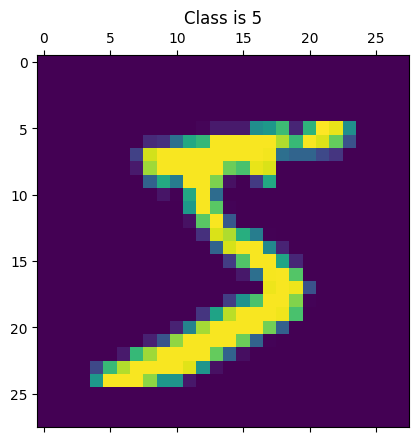

In [ ]:
import matplotlib.pyplot as plt
plt.matshow(X_train[0])
plt.title(f'Class is {y_train[0]}')

In [ ]:
## Preprocessing
# 0 to 255
import numpy as np
np.max(X_train), np.min(X_train)

(np.uint8(255), np.uint8(0))

In [ ]:
X_train = X_train/255
X_test = X_test/255

In [ ]:
np.max(X_train), np.min(X_train)

(np.float64(1.0), np.float64(0.0))

Text(0.5, 1.0, 'Class is 5')

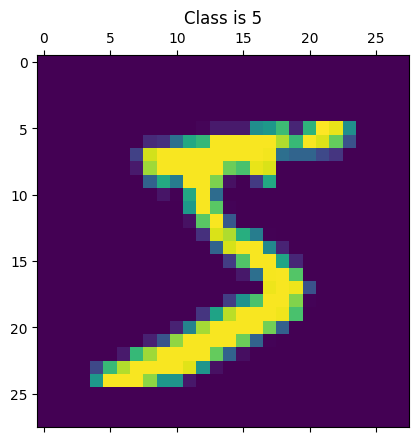

In [ ]:
import matplotlib.pyplot as plt
plt.matshow(X_train[0])
plt.title(f'Class is {y_train[0]}')

In [ ]:
# flatten() -> convert the multi dim featues into 1 dim
X_train = X_train.reshape(60000, 28*28)
X_test = X_test.reshape(10000,28*28)

In [ ]:
# Target
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [ ]:
# converting into hot encoding
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [ ]:
y_train[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [ ]:
from os import name
# construt the neutral network
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(28*28,),name='h1'))
model.add(Dense(128, activation='relu',name='h2'))
model.add(Dense(10, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers[0].get_weights()

[array([[ 0.01943017, -0.06794924, -0.02124858, ...,  0.04250836,
         -0.03192312,  0.02287343],
        [-0.04901883, -0.06062155, -0.05280852, ..., -0.04106187,
          0.00600363,  0.01459417],
        [ 0.05879235,  0.02805691, -0.03943921, ...,  0.05981341,
         -0.02575351, -0.06316733],
        ...,
        [ 0.05422725,  0.01570648,  0.02514992, ...,  0.04161583,
         -0.0625714 , -0.04412724],
        [-0.00455461, -0.0325496 , -0.05251116, ...,  0.02791083,
          0.05233996, -0.01706518],
        [-0.04660764,  0.01412164,  0.04141381, ..., -0.0705019 ,
         -0.03255397,  0.03296485]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [ ]:
model.compile(optimizer = 'rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(x=X_train,y=y_train,
                    epochs=25,
                    batch_size=32,
                    validation_data=(X_test,y_test)
                    )

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8980 - loss: 0.3382 - val_accuracy: 0.9674 - val_loss: 0.1092
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9719 - loss: 0.0937 - val_accuracy: 0.9685 - val_loss: 0.1066
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9811 - loss: 0.0649 - val_accuracy: 0.9785 - val_loss: 0.0771
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9857 - loss: 0.0505 - val_accuracy: 0.9755 - val_loss: 0.0858
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9883 - loss: 0.0408 - val_accuracy: 0.9791 - val_loss: 0.0893
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9905 - loss: 0.0327 - val_accuracy: 0.9801 - val_loss: 0.0832
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9922 - loss: 0.0273 - val_accuracy: 0.9803 - val_loss: 0.0914
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9936 - loss: 

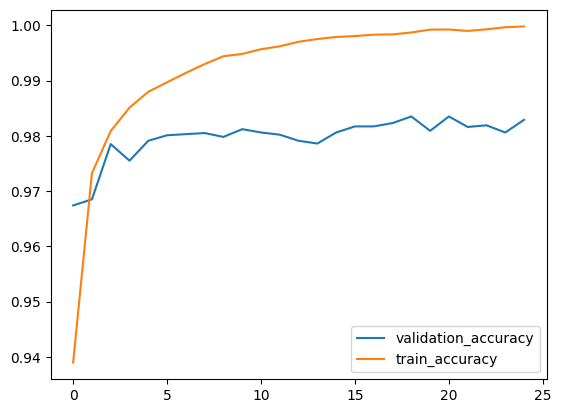

In [ ]:
h = history.history
plt.plot(h['val_accuracy'],label='validation_accuracy')
plt.plot(h['accuracy'],label='train_accuracy')
plt.legend()
plt.show()

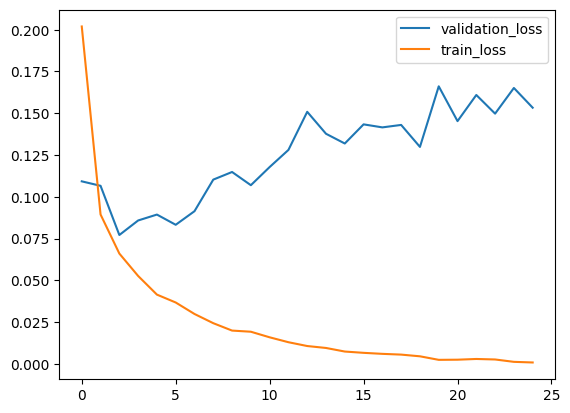

In [ ]:
plt.plot(h['val_loss'],label='validation_loss')
plt.plot(h['loss'],label='train_loss')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9803 - loss: 0.1891


[0.1533251255750656, 0.9829000234603882]